In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(67)

# Simulación y Distribución Empírica
Las distribuciones a usar serán: Bernoulli(0.67), Binomial(6,0.7), Poisson(67), Normal(6,7^2) y Exponencial(6.7).

In [5]:
data_ber = rng.binomial(1, 0.67, size=10000)
data_bin = rng.binomial(6, 0.7, size=10000)
data_poi = rng.poisson(67, size=10000)
data_nor = rng.normal(6 ,7 , size=10000)
data_exp = rng.exponential(scale=1/6.7, size=10000)

Generamos el dataframe una vez ya están listos los datos.


In [ ]:
df = pd.DataFrame({
    "Bernoulli" : data_ber,
    "Binomial" : data_bin,
    "Poisson" : data_poi,
    "Normal" : data_nor,
    "Exponencial" : data_exp,
})
df
df.to_csv("../data/raw/Tabla_de_realizaciones_T1P1.csv", index=False)

Luego, modelaremos histogramas para la distribución bernoulli y la normal.

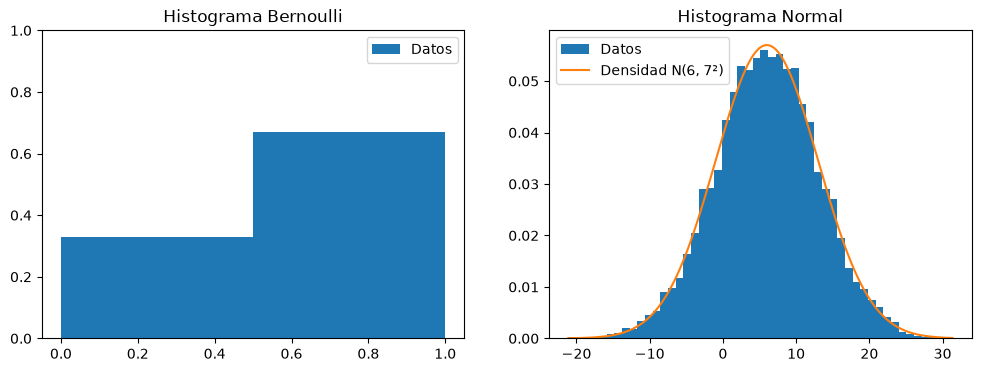

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
x = np.linspace(data_nor.min(), data_nor.max(), 10000)
axes[0].hist(data_ber, bins=2, weights=np.ones(len(data_ber)) / len(data_ber), label="Datos") #Normalizamos dando peso 1/n a todos los datos
axes[0].set_title("Histograma Bernoulli"); axes[0].set_ylim(0, 1); axes[0].legend() #Que vaya de 0 a 1 en el eje Y deja más entendible las proporciones
axes[1].hist(data_nor, bins=50, density=True, label="Datos") #Density funciona mejor con continuos

mu = 6
sigma = 7

densidad = (1 / (sigma * np.sqrt(2 * np.pi))) * \
           np.exp(-((x - mu)**2) / (2 * sigma**2))

axes[1].plot(x, densidad, label="Densidad N(6, 7²)")
axes[1].set_title("Histograma Normal");axes[1].legend()



# Ley de los Grandes Números
Construímos el desarrollo del promedio empírico a partir de operar el array de suma acumulada a partir de un vector que indexa el largo de los datos.

In [21]:
promedio_empírico_ber = np.cumsum(data_ber)/np.arange(1,len(data_ber)+1)
promedio_empírico_bin = np.cumsum(data_bin)/np.arange(1,len(data_bin)+1)
promedio_empírico_poi = np.cumsum(data_poi)/np.arange(1,len(data_poi)+1)
promedio_empírico_nor = np.cumsum(data_nor)/np.arange(1,len(data_nor)+1)
promedio_empírico_exp = np.cumsum(data_exp)/np.arange(1,len(data_exp)+1)
dfpe = pd.DataFrame({
    "Bernoulli" : promedio_empírico_ber,
    "Binomial" : promedio_empírico_bin,
    "Poisson" : promedio_empírico_poi,
    "Normal" : promedio_empírico_nor,
    "Exponencial" : promedio_empírico_exp,
})
dfpe

,Bernoulli,Binomial,Poisson,Normal,Exponencial
0,0.000000,4.000000,76.000000,0.169226,0.107691
1,0.500000,3.500000,73.500000,3.912439,0.079789
2,0.333333,4.333333,72.666667,3.011770,0.141344
3,0.250000,4.000000,71.750000,2.245657,0.200508
4,0.400000,4.000000,69.800000,2.935372,0.201429
...,...,...,...,...,...
9995,0.671168,4.191377,67.032313,5.977059,0.148245
9996,0.671201,4.191257,67.031910,5.977217,0.148233
9997,0.671234,4.191238,67.032907,5.977269,0.148245
9998,0.671267,4.191219,67.031903,5.977229,0.148277


Graficaremos la evolución del promedio empírico de las distribuciones de Bernoulli y Normal con respecto a las realizaciones.

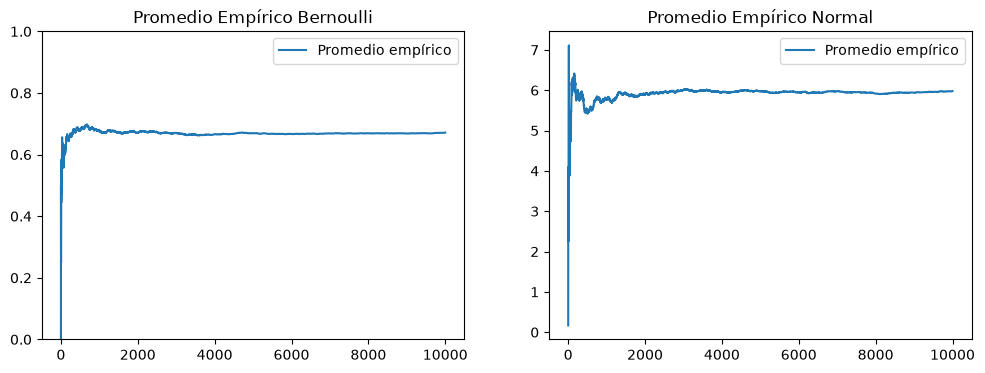

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(np.arange(1,len(data_ber)+1), promedio_empírico_ber, label="Promedio empírico")
axes[0].set_title("Promedio Empírico Bernoulli"); axes[0].set_ylim(0,1); axes[0].legend()
axes[1].plot(np.arange(1,len(data_nor)+1), promedio_empírico_nor, label="Promedio empírico")
axes[1].set_title("Promedio Empírico Normal");  axes[1].legend()

Notamos que, para $ X$ ~ $Ber(0.67)$, $Y$ ~ $Nor(6,7^2) $:
$$
E[X]= 0*P(X=0)+1*P(X=1)=1*0.67=0.67
$$
y
$$

E[Y]= \int_{-\infty}^{\infty} y \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(y-\mu)^2}{2\sigma^2}} \,dy = \int_{-\infty}^{\infty} (\mu + z\sigma) \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{z^2}{2}} \sigma \,dz = \int_{-\infty}^{\infty} (\mu + z\sigma) \frac{1}{\sqrt{2\pi}} e^{-\frac{z^2}{2}} \,dz
$$
$$
= \mu\int_{-\infty}^{\infty}\frac{1}{\sqrt{2\pi}} e^{-\frac{z^2}{2}} \,dz + \sigma\int_{-\infty}^{\infty} z\frac{1}{\sqrt{2\pi}} e^{-\frac{z^2}{2}} \,dz

$$
Dónde la primera integral es equivalente a $ E_{N(0,1)}[1]= \int_{-\infty}^{\infty}\frac{1}{\sqrt{2\pi}} e^{-\frac{z^2}{2}} \,dz = 1 $ y la segunda es una integral de una función impar luego es 0, sigue que $E[Y]=\mu$

Sabiendo que son distribuciones con esperanza 0.67 y 6 respectivamente, el comportamiento del promedio empírico parece indicar que a medida que se hacen más realizaciones de las variables, estas se acercan al valor de la esperanza. Esto es, en principio, lo que postula la ley de grandes números.

# TCL
Para el estudio del TCL usaremos la variable con distribución de bernoulli, armaremos colleciones de 100 realizaciones de la variable bernoulli, y contruiremos un array de la siguiente forma:
$$
(Z)_{i} = \frac{10(\frac{1}{100}\sum_{i=1+(i-1)*100}^{i*100} X_i-\mu)}{\sigma}
$$
con $\mu = 0.67$, y $\sigma^2 = 0.67*0.33$

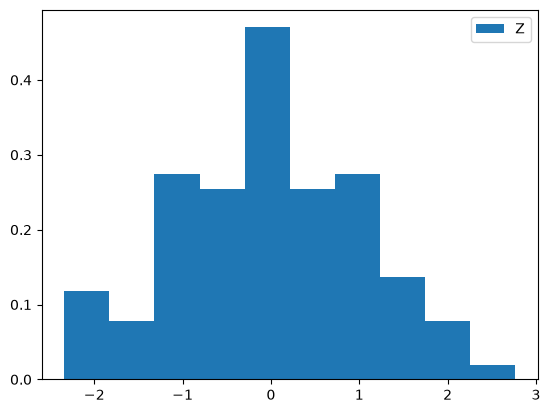

In [38]:
mu = 0.67
sigma = np.sqrt(0.67*0.33)

muestras = data_ber.reshape(-1, 100)
promedios = muestras.mean(axis=1)
Z = 10 * (promedios - mu) / sigma

plt.hist(Z, bins=10, density=True, label="Z")
plt.legend()


La distribución se asemeja a la de una distribución N(0,1), sin embargo a pesar de tratarse de 10000 datos, la distribución es poco suave a diferencia de la proximitud del promedio a la esperanza, esto se puede deber a la cantidad de datos necesarios para poder tomar promedios de muchos datos tal que sean independientes.